# Модель поведенческого скринга для прогноза просрочек по кредитам 

---
# Описание

### Общая информация
- заказчик проекта: крупный розничный банк
- Массовые просрочки по кредитным платежам могут запустить цепную реакцию: рост резервов -> снижение ликвидности -> риск закрытия банка.

### Бизнес задача
- разработать инструмент прогноза просрочек платежей, опираясь на текущее поведение клиентов. Точный прогноз просрочек платежа позволяет управлять ликвидностью, то есть сглаживать резкие колебания.

### Цель
- разработать модель поведенческого скоринга, которая по данным о клиенте в выбранный месяц прогнозирует, возникнет ли у него просрочка на 90 дней или более.​

### ML задача

Вид задачи:
- тип: обучение с учителем
- подтип: классификация

Целевая переменная:
- бинарный признак: 1 - просрочка была, 0 - просрочки не было. Строится по принципу скользящего окна

Особенности:
- необходимо использовать горизонт прогноза 12 месяцев
- У одного и того же клиента значения целевой переменной могут различаться от месяца к месяцу. Даже если клиент ранее уже был в дефолте, в следующие месяцы он мог выплатить долг и вернуться к значению 0 целевой переменной

Ключевые метрики:
- Approval rate, «уровень одобрения» = $\frac{FN + TN}{N}$
- Default rate, «доля просрочек платежа» = $\frac{FN}{FN + TN}$
- Missed defaults rate, «доля пропущенных дефолтов» = $\frac{FN}{FN + TP} = 1 - Recall$ 


Требования по качеству модели:
- Approval rate не менее 65%
- Default rate не более 2%
- Missed defaults rate не более 4%

---
## 1. Настройка проекта и загрузка данных

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
import requests
import warnings
from phik import phik_matrix
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from typing import Optional, Union, Dict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
import optuna 
from sklearn.preprocessing import FunctionTransformer
    

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# воспроизводимость  вычислений
RANDOM_SEED = 42 

In [4]:
# настройки визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)

### Загрузка данных

In [5]:
# пути к файлам
path_s: list[str] = [
    'https://code.s3.yandex.net/datasets/ds_15_loan_payment_credit.csv',
    'https://code.s3.yandex.net/datasets/ds_15_transactions.csv',
    'https://code.s3.yandex.net/datasets/ds_15_client_description.csv',
    'https://code.s3.yandex.net/datasets/ds_15_credit_description.csv',
    'https://code.s3.yandex.net/datasets/ds_15_mortgage_presence.csv',
    'https://code.s3.yandex.net/datasets/ds_15_credit_rating.csv',
    'https://code.s3.yandex.net/datasets/ds_15_macro_data.csv',
    'https://code.s3.yandex.net/datasets/ds_15_cohort_grid.csv',
]

In [6]:
def read_show_info(path: str) -> pd.DataFrame:
    """Чтение csv файла по ссылке и отображение базовой информации о датасете"""

    df = pd.read_csv(path)
    display(df.info(), df.head(5))

    return df

In [7]:
df_loan_payment_credit = read_show_info(path_s[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   5500 non-null   object
 1   дата_начала_периода  5500 non-null   object
 2   просрочка_дней       5500 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 129.0+ KB


None

,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


In [8]:
df_transactions = read_show_info(path_s[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          577494 non-null  object 
 1   date        577494 non-null  object 
 2   MCC_5300    577494 non-null  float64
 3   MCC_5814    577494 non-null  float64
 4   MCC_5812    577494 non-null  float64
 5   MCC_5411    577494 non-null  float64
 6   MCC_3990    577494 non-null  float64
 7   MCC_5722    577494 non-null  float64
 8   MCC_4900    577494 non-null  float64
 9   MCC_другое  577494 non-null  float64
dtypes: float64(8), object(2)
memory usage: 44.1+ MB


None

,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.99,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.76,2156.67,1519.46,4352.90


In [9]:
client_description = read_show_info(path_s[2])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  13500 non-null  object
 1   возраст             13500 non-null  int64 
 2   семейное_положение  13500 non-null  object
 3   наличие_иждивенцев  13500 non-null  int64 
 4   дата_регистрации    13500 non-null  object
dtypes: int64(2), object(3)
memory usage: 527.5+ KB


None

,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01


In [10]:
credit_description = read_show_info(path_s[3])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             13500 non-null  object
 1   доход          13500 non-null  int64 
 2   сумма_кредита  13500 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 316.5+ KB


None

,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870


In [11]:
df_mortgage_presence = read_show_info(path_s[4])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID               6609 non-null   object
 1   дата_открытия    6609 non-null   object
 2   наличие_ипотеки  6609 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 155.0+ KB


None

,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1


In [12]:
df_credit_rating = read_show_info(path_s[5])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ID                 577494 non-null  object
 1   date               577494 non-null  object
 2   кредитный_рейтинг  577494 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 13.2+ MB


None

,ID,date,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688


In [13]:
df_macro_data = read_show_info(path_s[6])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 84 non-null     object 
 1   учетная_ставка       84 non-null     float64
 2   уровень_безработицы  84 non-null     float64
 3   инфляция             84 non-null     float64
dtypes: float64(3), object(1)
memory usage: 2.8+ KB


None

,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66


In [14]:
df_cohort_grid = read_show_info(path_s[7])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ID          577494 non-null  object
 1   score_date  577494 non-null  object
dtypes: object(2)
memory usage: 8.8+ MB


None

,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


In [15]:
df_list = [
    pd.read_csv(path) for path in path_s
]

In [16]:
df_names = [
    'loan_payment_credit',
    'transactions',
    'client_description',
    'credit_description',
    'mortgage_presence',
    'credit_rating',
    'macro_data',
    'cohort_grid',
]

Итог:
- загрузка данных прошла корректно: типы данных соответствуют описанию

Анализ:
- данные содержат временные ряды. При дальнейшем анализе важно сохранять сортировку по датам 
- для макроэкономических показателей объединение будет проходить по дате. Для остальных таблиц объединение возможно по ID клиентов. 
- явных пропусков в данных нет


## 2. Исследовательский анализ данных


In [17]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', 'category']
NUM_COLS_TYPES = [np.number]

In [18]:
def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

def get_base_df_info(name: str, df: pd.DataFrame):
    """Информация о датафрейме для ИАД анализа"""
    
    rows_count, cols_count = df.shape
    missing = df.isna().sum()
    missing_share = (missing / rows_count * 100).round(2) if rows_count else pd.Series(0, index=df.columns, dtype=float)
    duplicates_count = (df.duplicated().sum() / rows_count * 100).round(2)
    unique_values = df.nunique(dropna=False)

    cat_cols, num_cols = get_cat_num_cols(df=df)

    overview_df = pd.DataFrame({
        'Метрика': ['Строк', 'Колонок', 'Явных дубликатов, %', 'Категориальных колонок', 'Числовых колонок'],
        'Значение': [rows_count, cols_count, duplicates_count, int(len(cat_cols)), int(len(num_cols))],
    })

    summary_df = pd.DataFrame({
        'Тип данных': df.dtypes.astype(str),
        'Пропуски': missing,
        'Доля пропусков, %': missing_share,
        'Уникальные значения': unique_values,
    }).sort_values(by=['Пропуски', 'Уникальные значения'], ascending=[False, False])

    cols_df = pd.DataFrame({
        'Категориальные колонки': pd.Series(cat_cols),
        'Числовые колонки': pd.Series(num_cols),
    })

    print(f'Общая информация о датафрейме {name}')
    display(df.head())
    display(overview_df)

    print('Сводка по признакам')
    display(summary_df)

    print('Типы колонок')
    display(cols_df)
    print('-'*50)

### Анализ таблиц 

- размеры, типы данных, пропуски, дубли

In [19]:
for name, data_frame in zip(df_names, df_list):
    get_base_df_info(name=name, df=data_frame)

Общая информация о датафрейме loan_payment_credit


,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


,Метрика,Значение
0,Строк,5500.0
1,Колонок,3.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,2.0
4,Числовых колонок,1.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
ID,object,0,0.0,5500
дата_начала_периода,object,0,0.0,73
просрочка_дней,int64,0,0.0,71


...

Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
ID,object,0,0.0,13500
score_date,object,0,0.0,84


Типы колонок


,Категориальные колонки,Числовые колонки
0,ID,NaN
1,score_date,NaN


--------------------------------------------------


Анализ:
- в таблице по наличию ипотеки все 6609 значения константные и равны 1. При объединении будем предполагать, что у остальных этот признак равен 0 (то есть ипотеки нет)
- данные не содержат дублей и пропусков

### Анализ распределений 

#### Числовые данные

In [34]:
def plot_hist_box(
    df: pd.DataFrame, feature_name: str,
    df_name: str,
    x_label: str = 'значение',
):
    fig, axes = plt.subplots(nrows=2, ncols=1)
    axes[0].grid(True)
    axes[1].grid(True)
    sns.histplot(data=df, x=feature_name, stat='density', ax=axes[0])
    sns.boxplot(data=df, x=feature_name, orient="h", ax=axes[1], label=f"{df[feature_name].describe()}")
    axes[0].set_title(f'Распределение признака {feature_name} в датасете {df_name}')
    axes[0].set_ylabel('плотность')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(feature_name)
    axes[1].legend(fontsize="x-small", loc='upper right')
    plt.show()

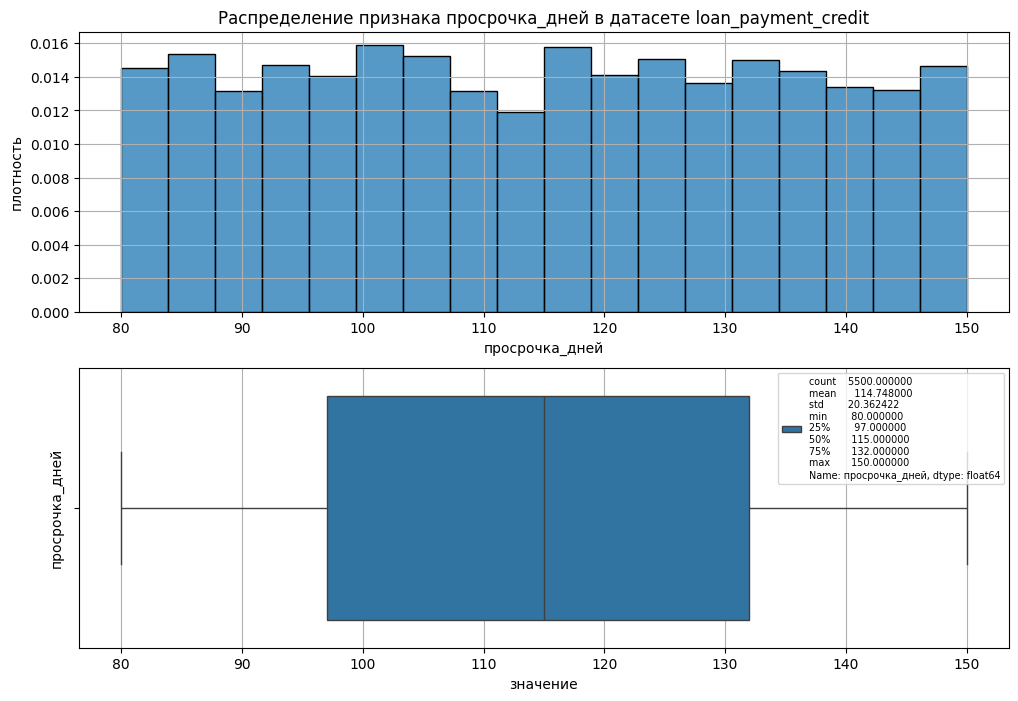

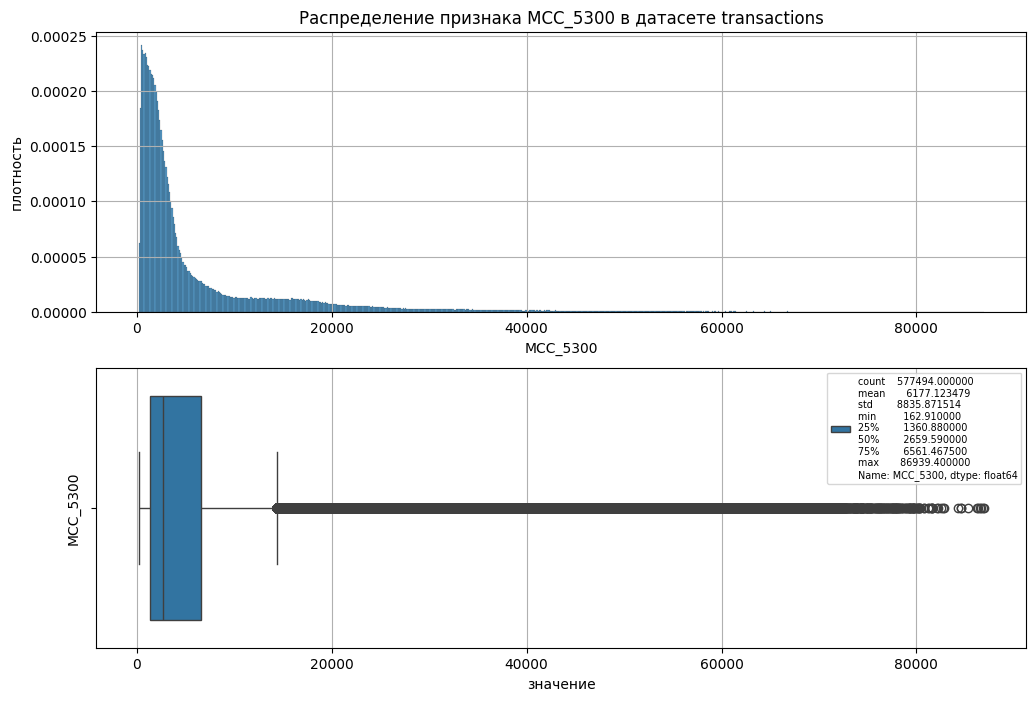

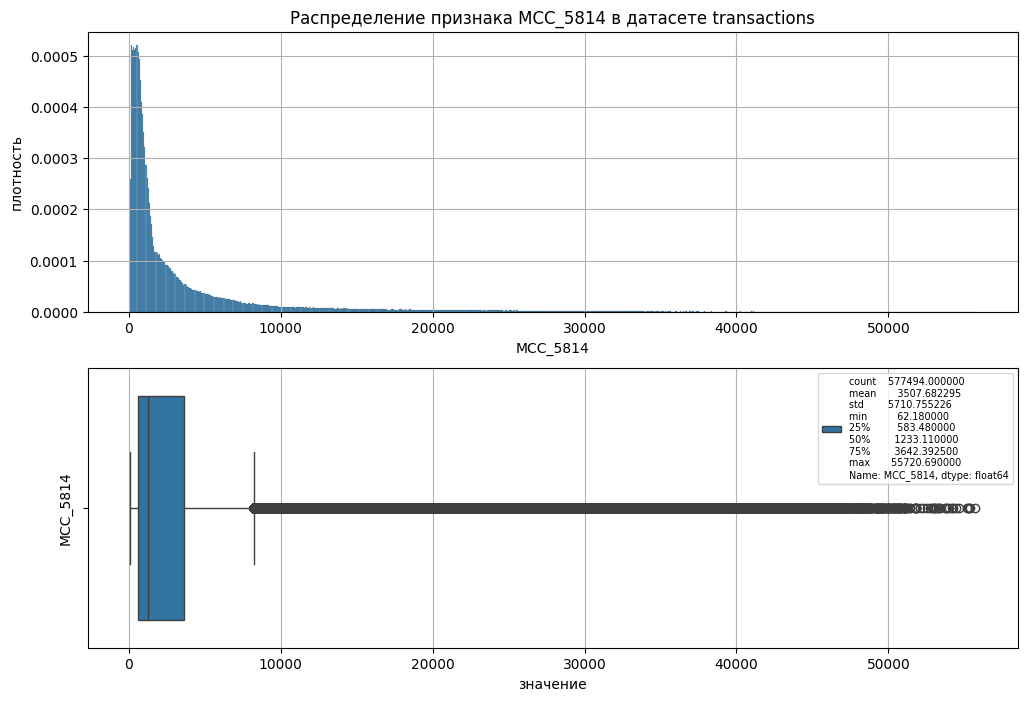

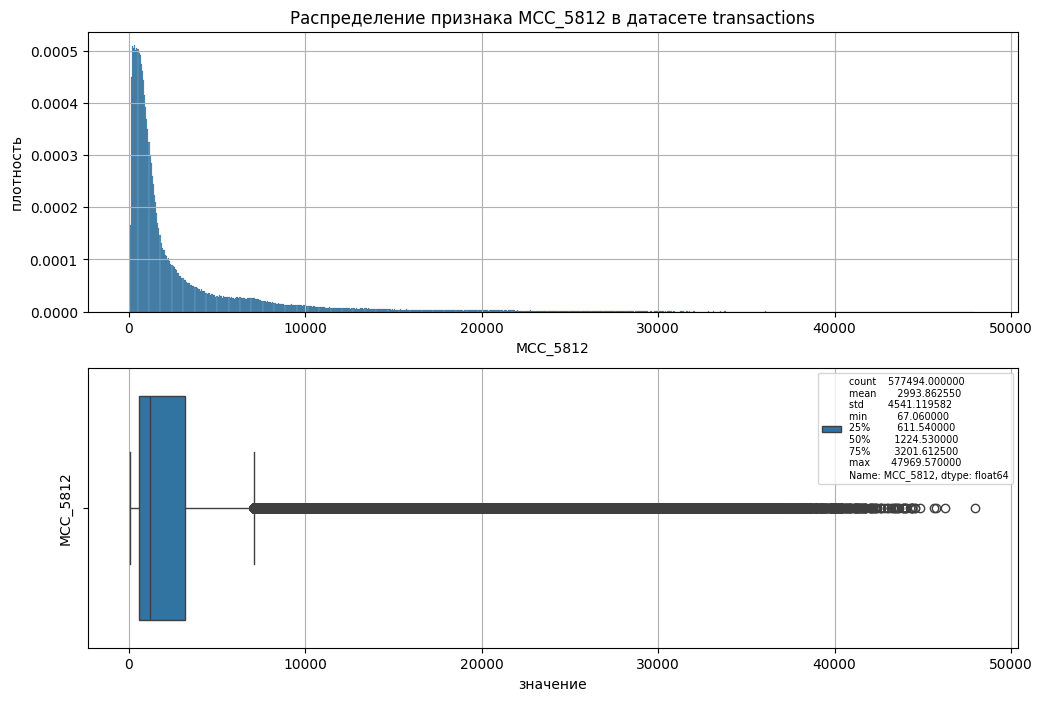

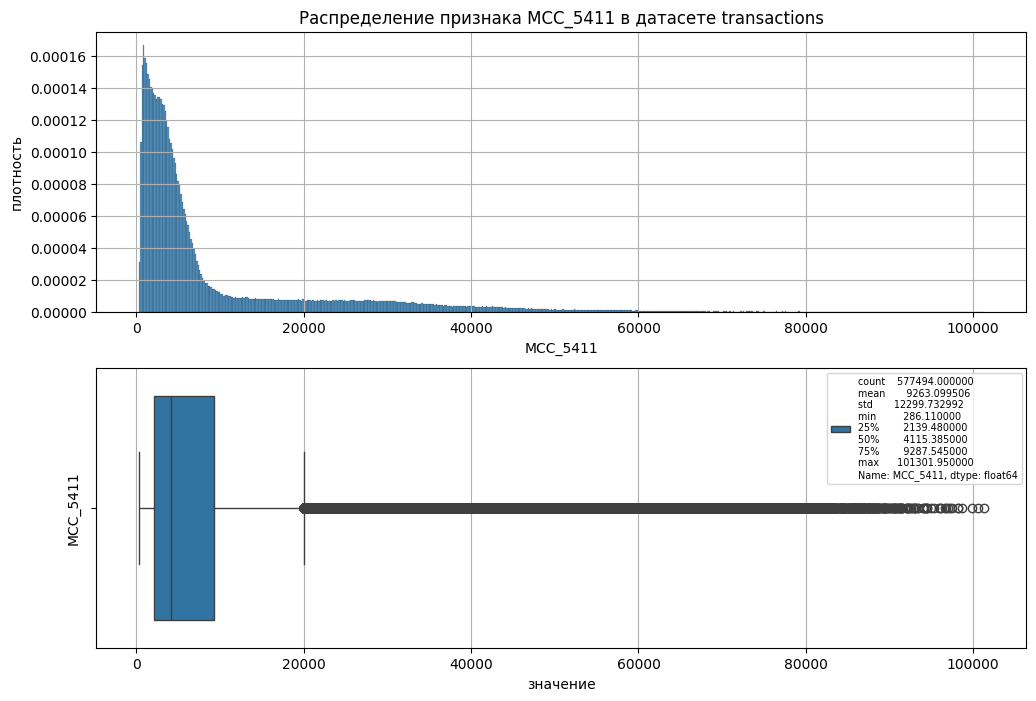

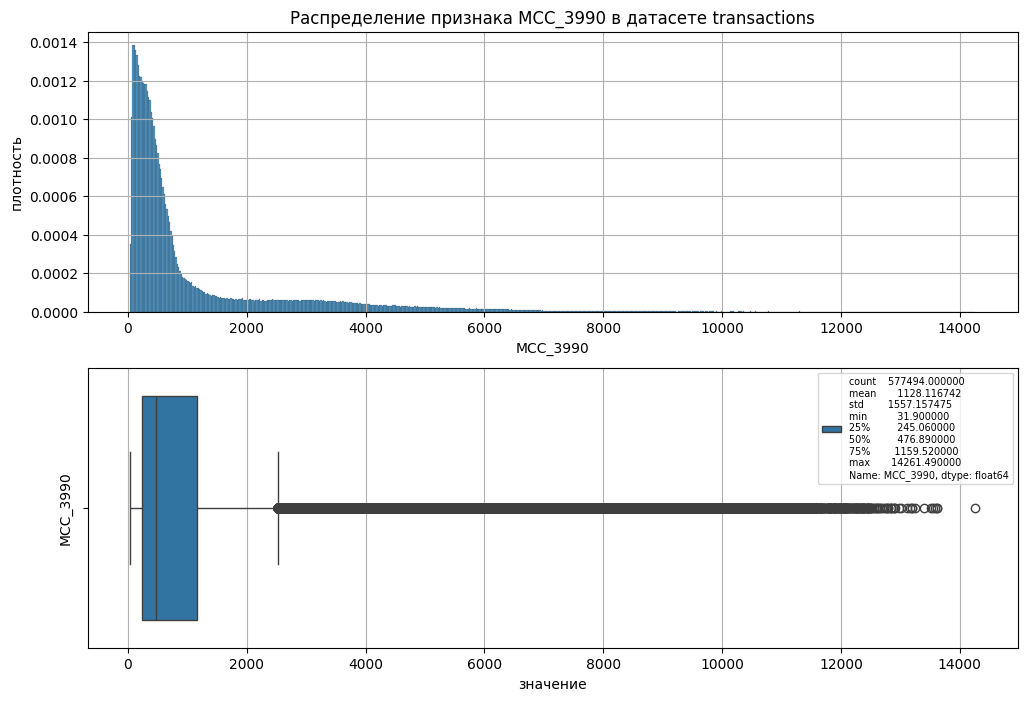

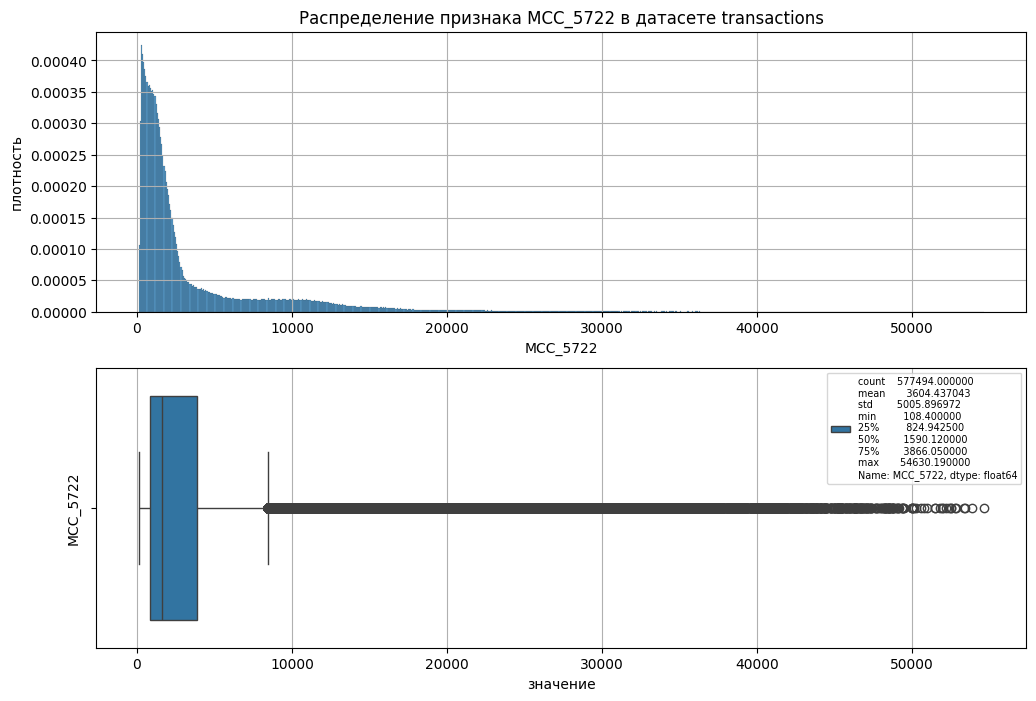

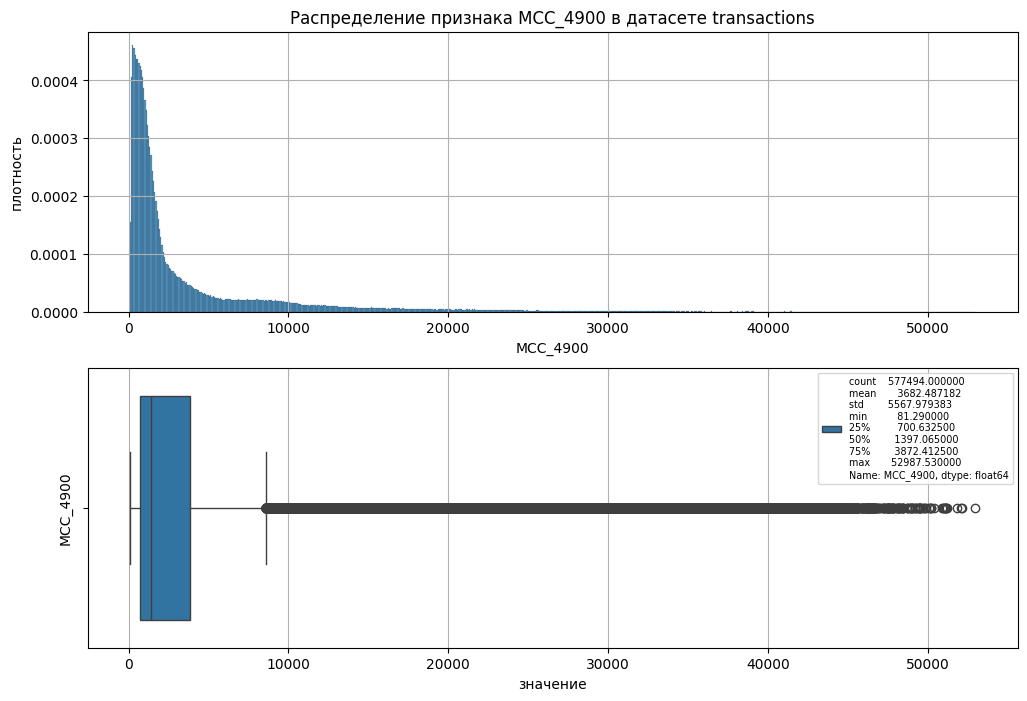

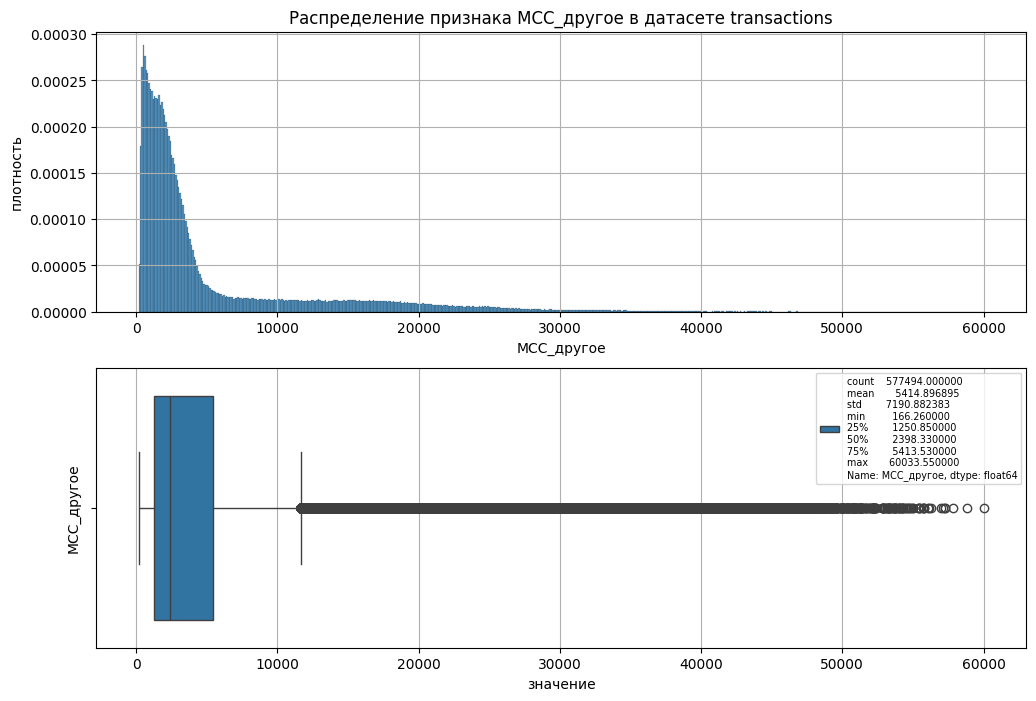

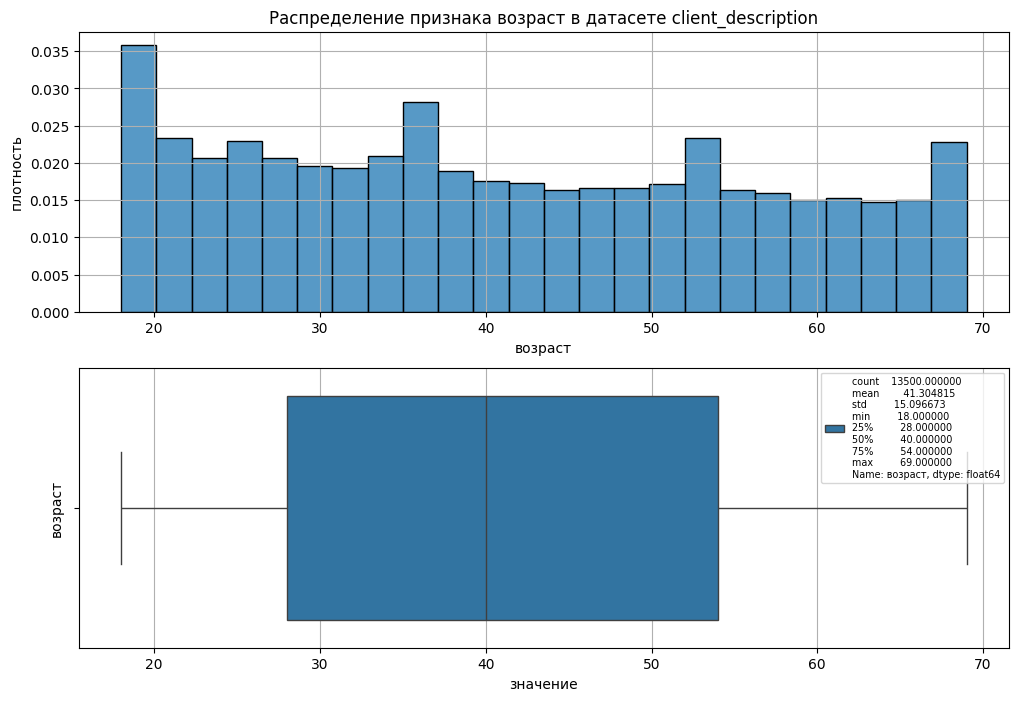

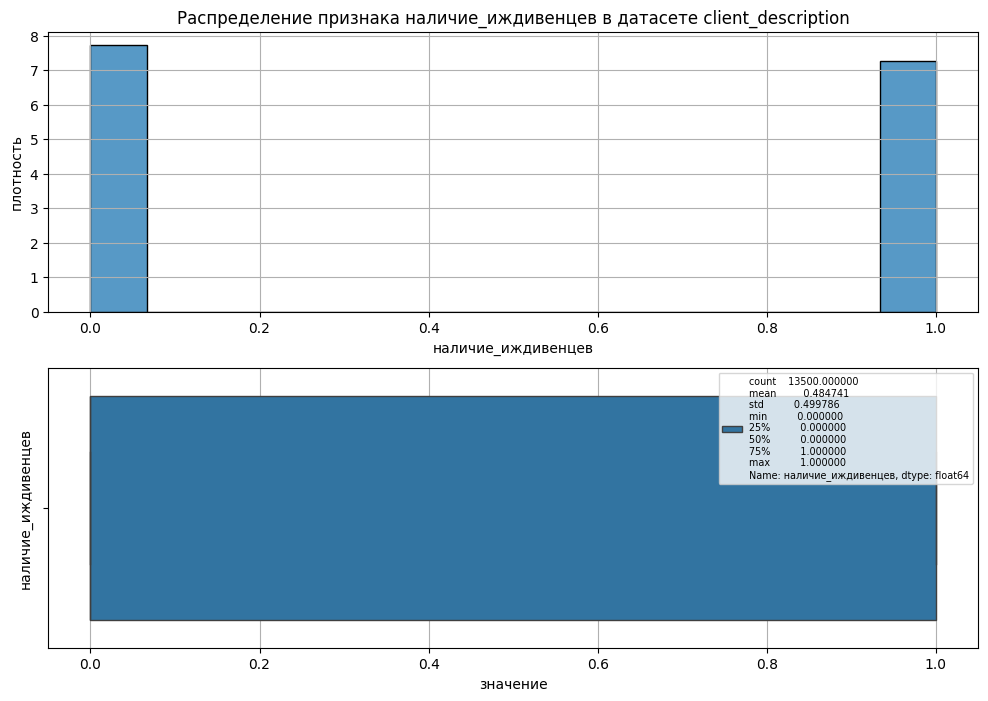

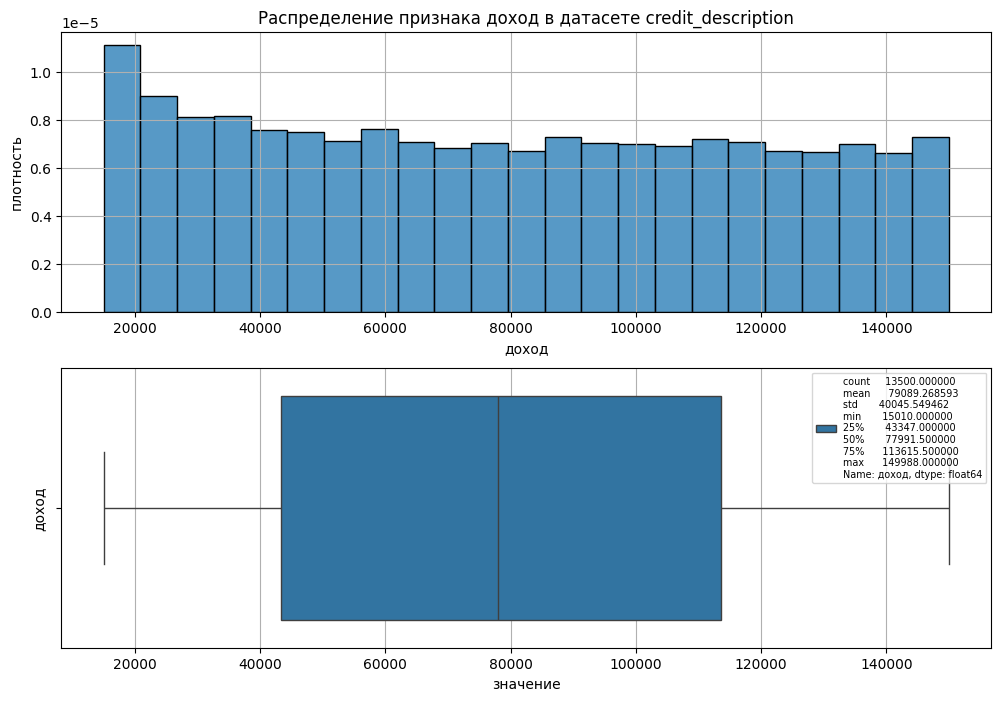

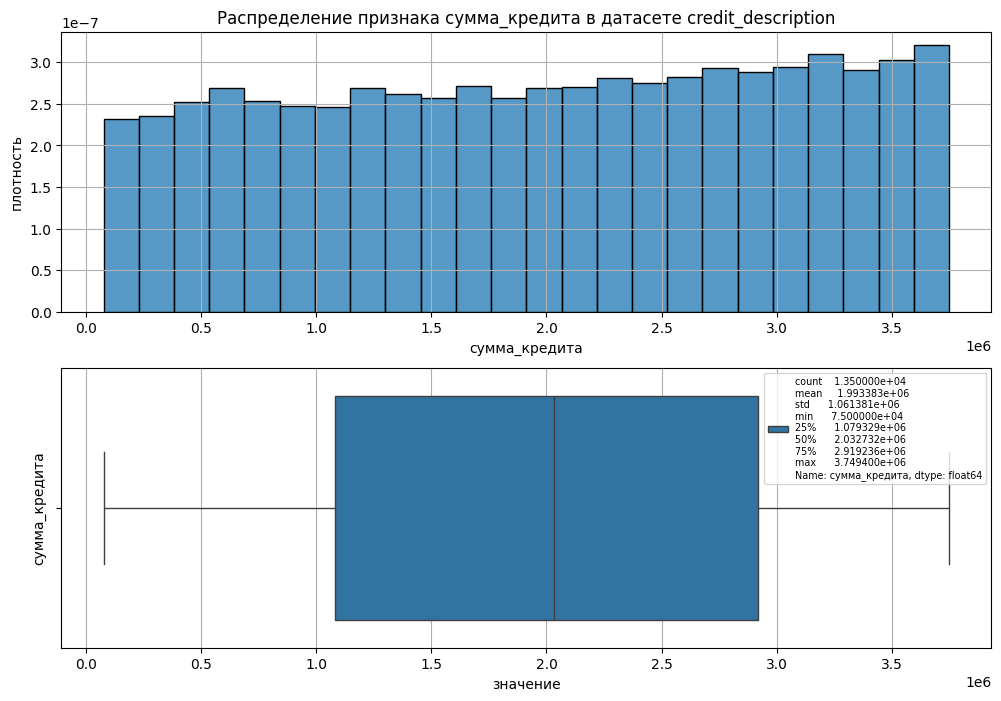

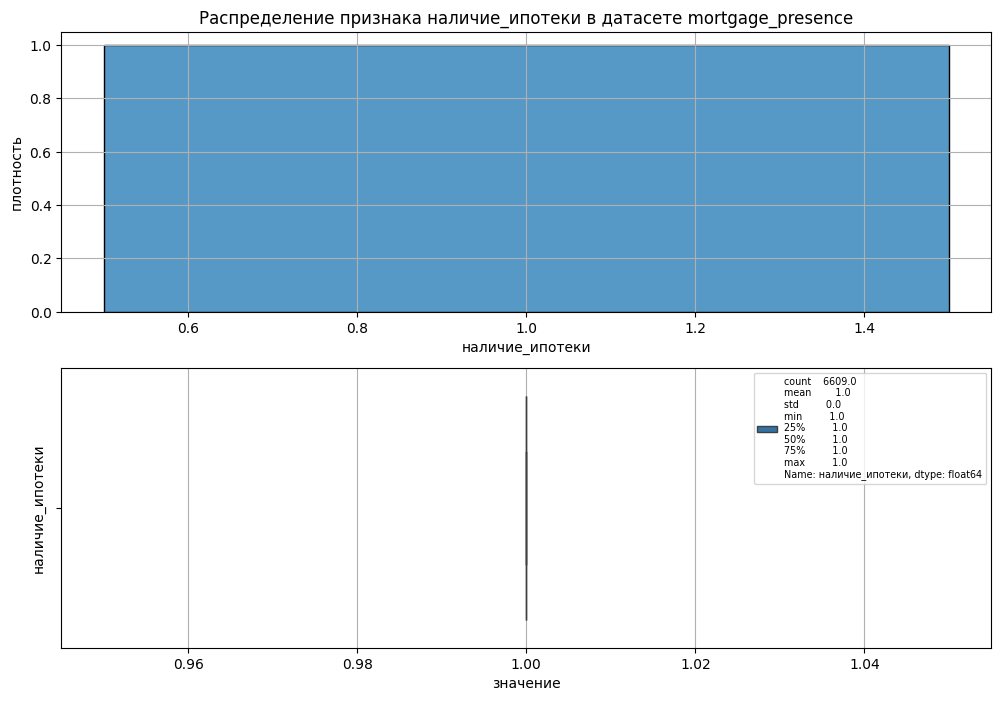

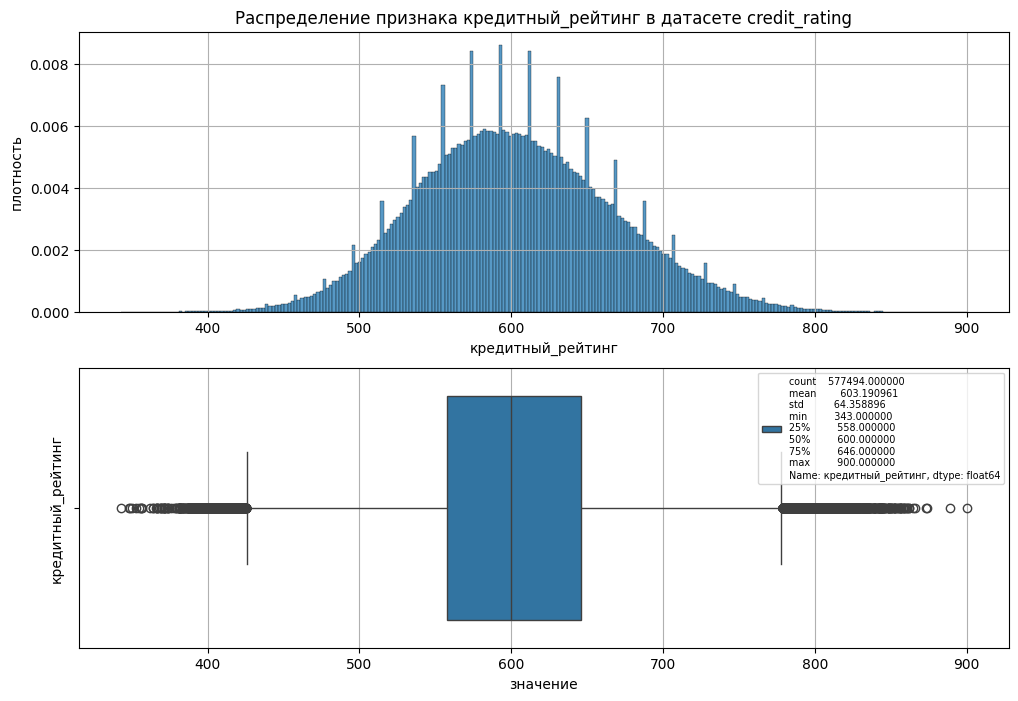

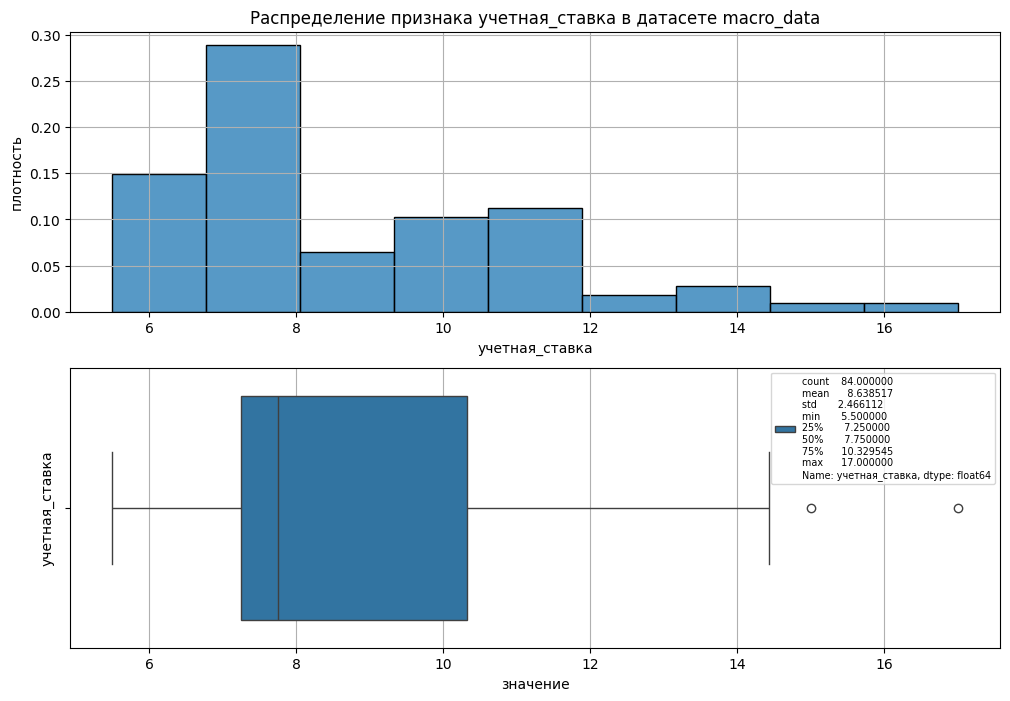

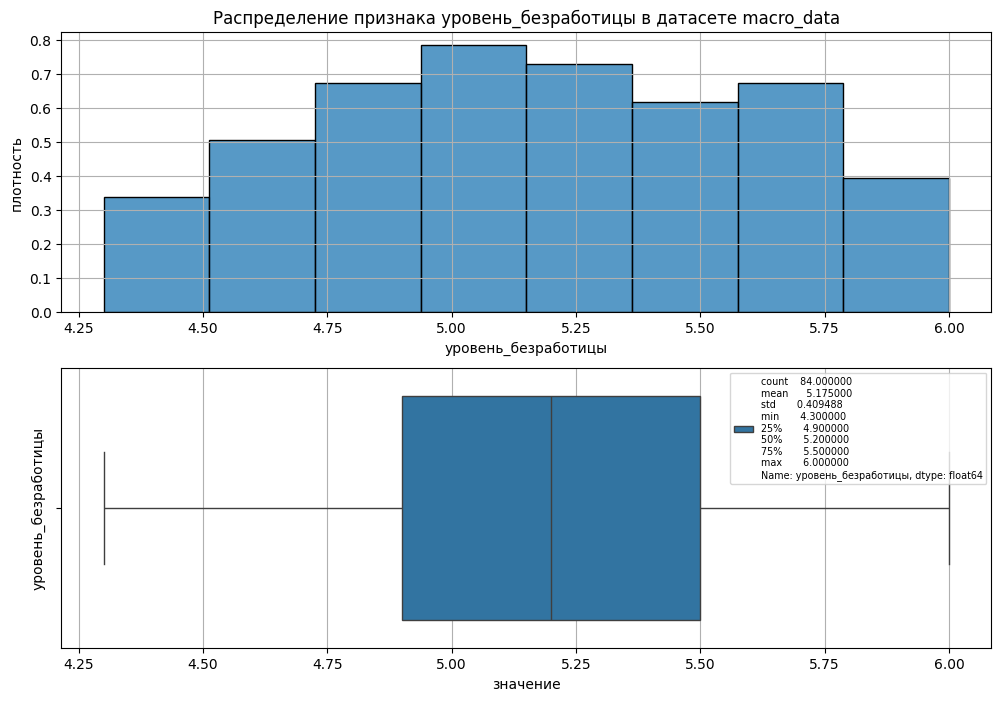

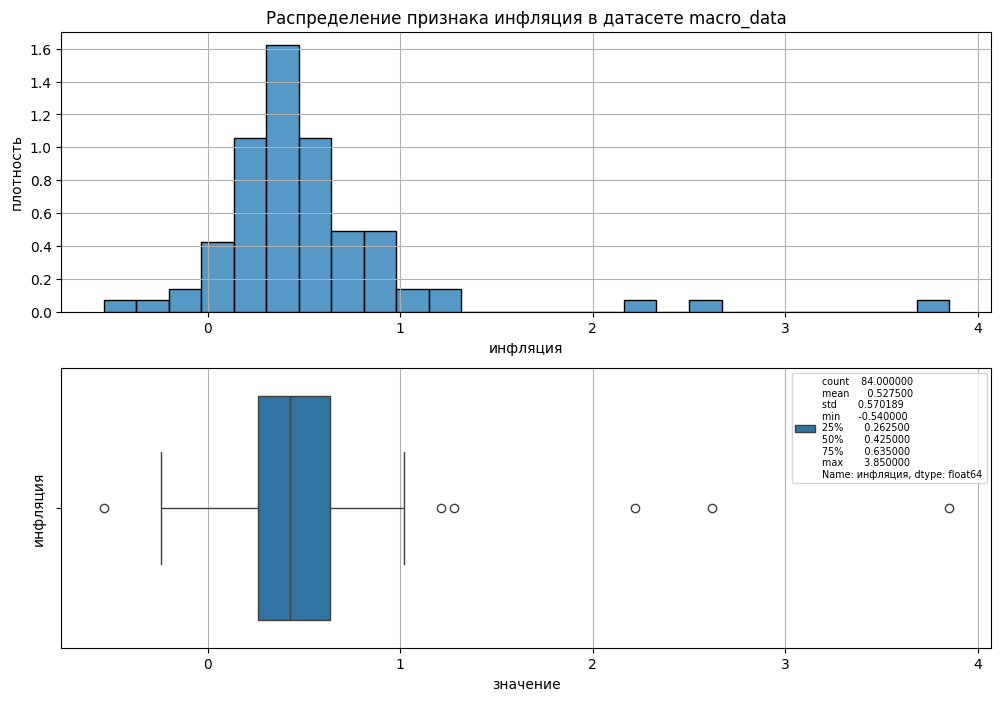

In [35]:
for df, df_name in zip(df_list, df_names):
    _, num_col_names = get_cat_num_cols(df)
    for name in num_col_names:
        plot_hist_box(df=df, feature_name=name, df_name=df_name)

Анализ:
- значение дней просрочек равномерно распределено по диапазону
- траты по кодам MCC имеют скошенное влево распределение. Присутствуют малочисленные выбросы -- большие траты
- возрастные группы представлены равномерно 
- наличие иждевенцев представлено в примерно равных долях 
- по доходу распределение равномерное 
- по сумме кредита распределение равномерное
- данные по наличию ипотеки принимают одно значнение - 1
- распределение по кредитному рейтингу симметричное, присутсвуют выбросы по краям. Имеются сгустки плотности на некоторых значениях. Возможно, это результат округления или стандратные крейтинги для каких-то категорий граждан
- Распределение по учетной ставке несимметричное, имеет малый набор уникальных значений. 
- По безработице распределение симметричное без выбросов
- По инфляции распределение симметричное, есть выбросы 

#### Категориальные данные

In [38]:
def plot_count_bars(
    df: pd.DataFrame, col_name: str, df_name: str
):
    """Столбчатые диаграммы распрелелений категориальных признаков"""
    df = df.sort_values(by=name) # сортировка по значениям
    sns.countplot(data=df, x=col_name)
    plt.title(f'Распределение признака {col_name} в датасете {df_name}')
    plt.ylabel('количество')
    plt.xticks(rotation=45)
    plt.show()

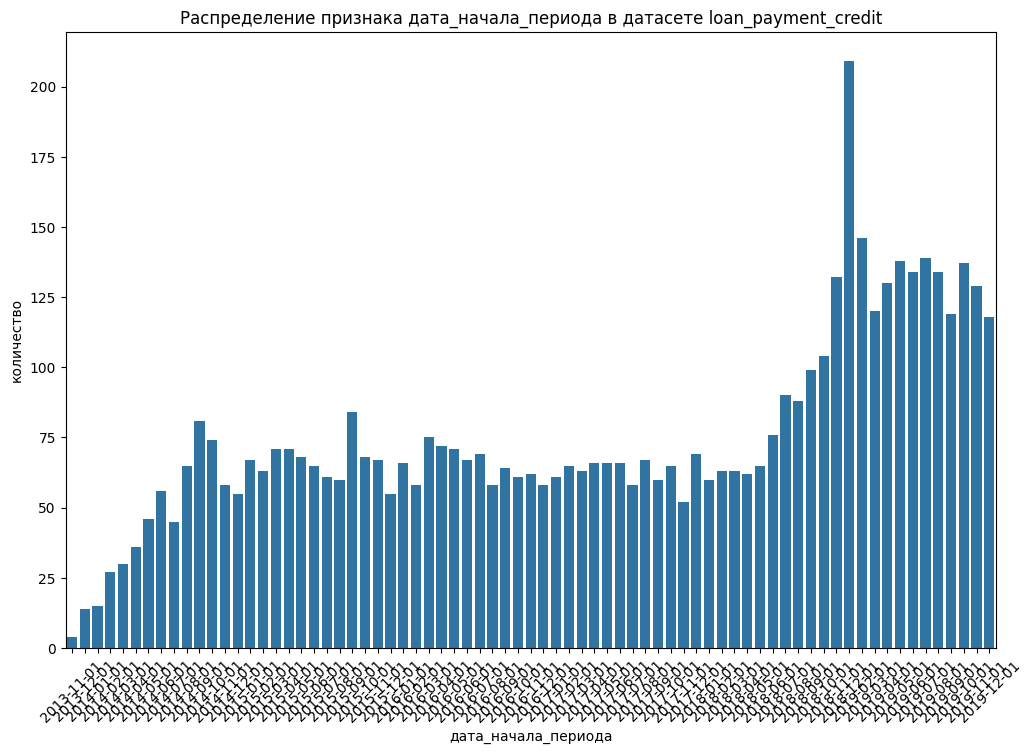

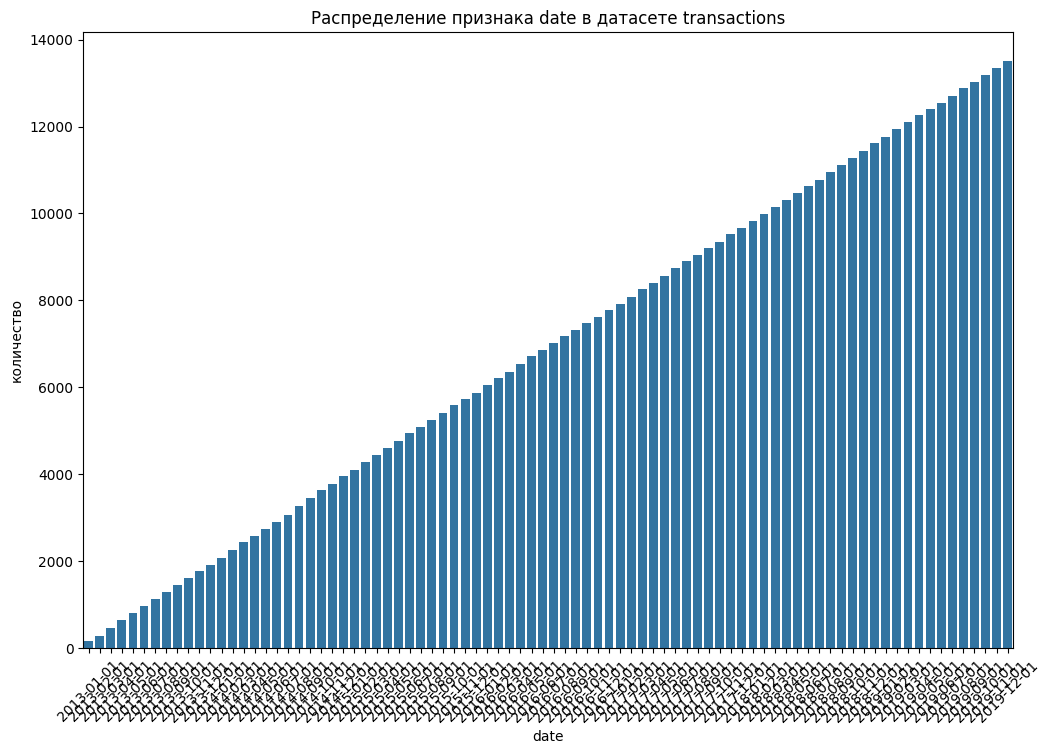

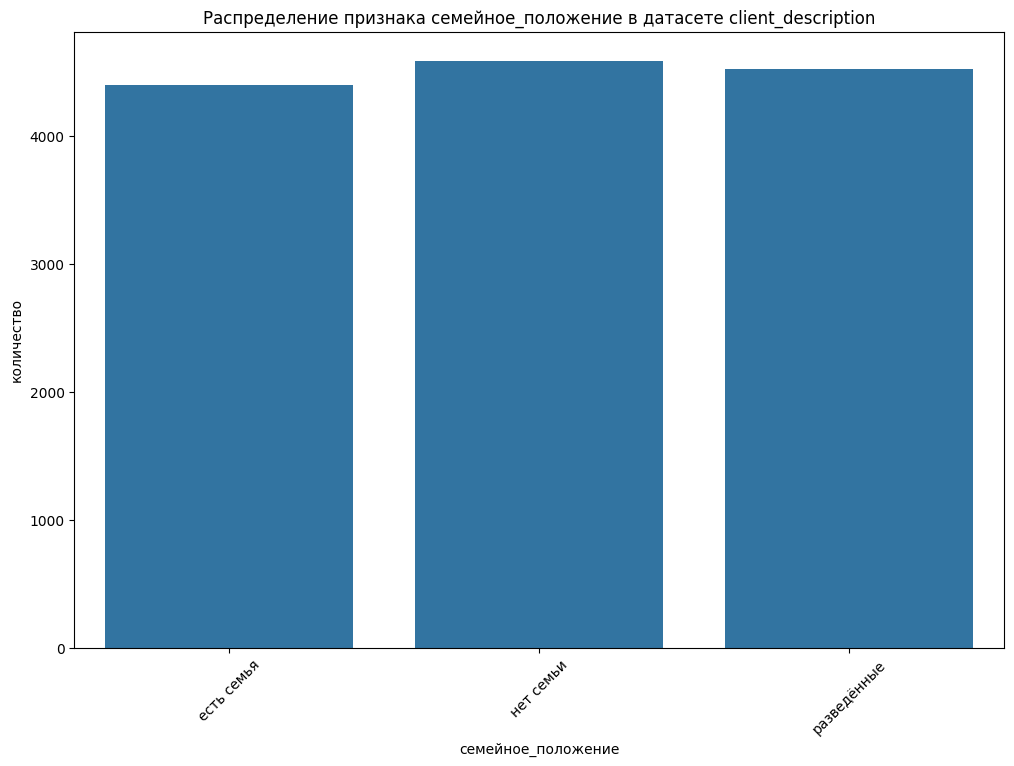

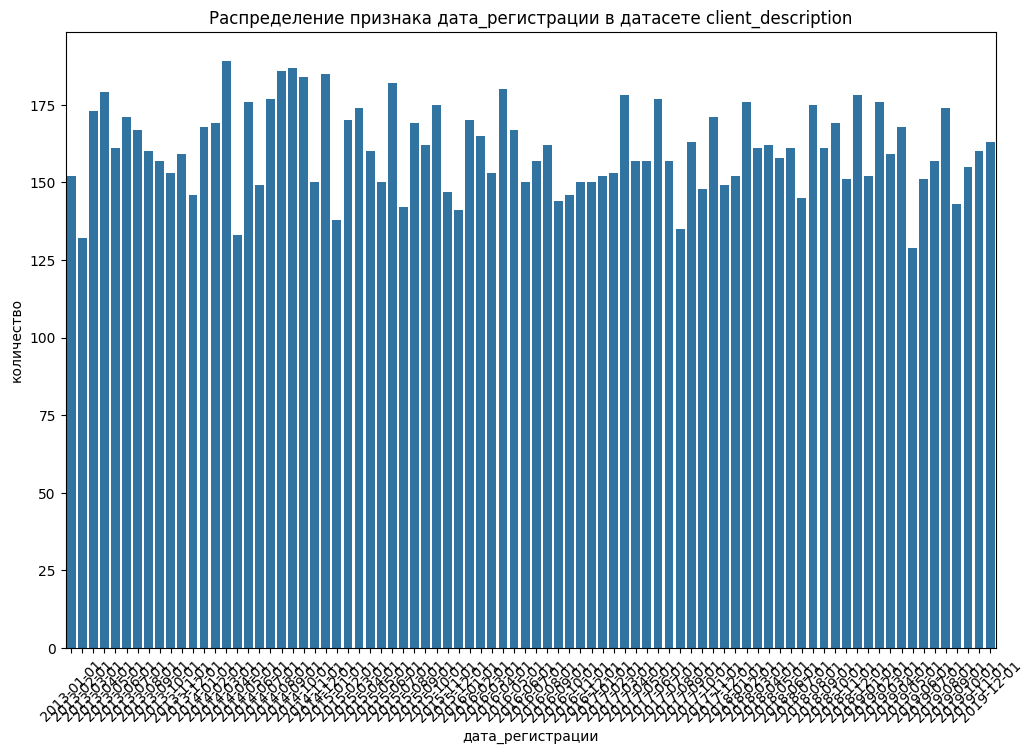

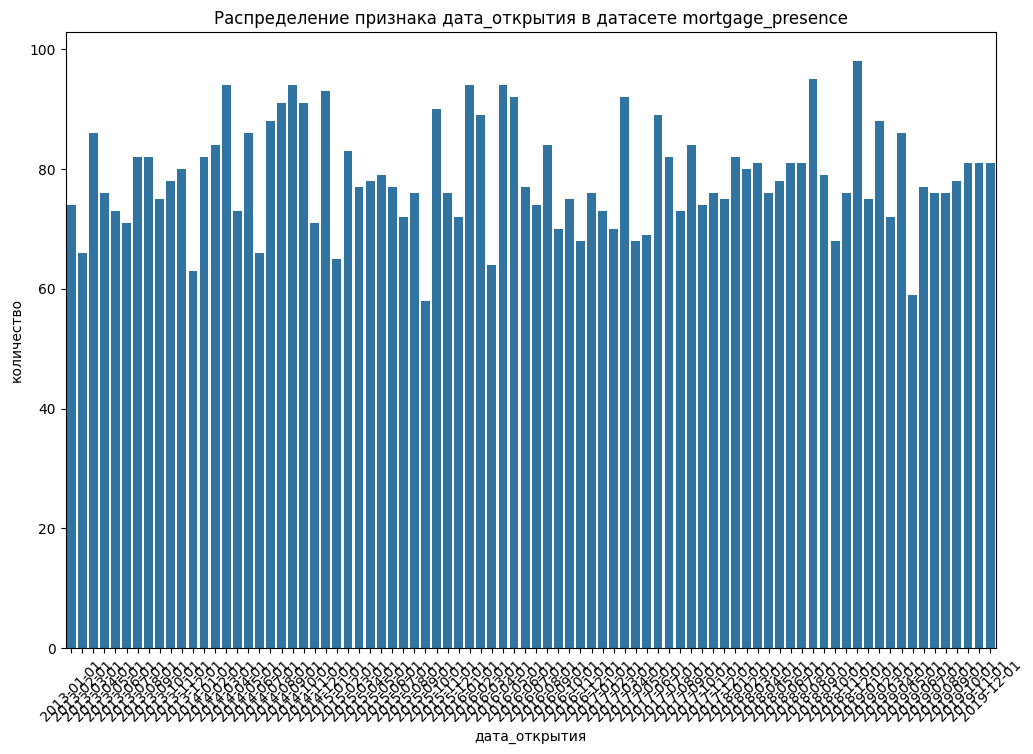

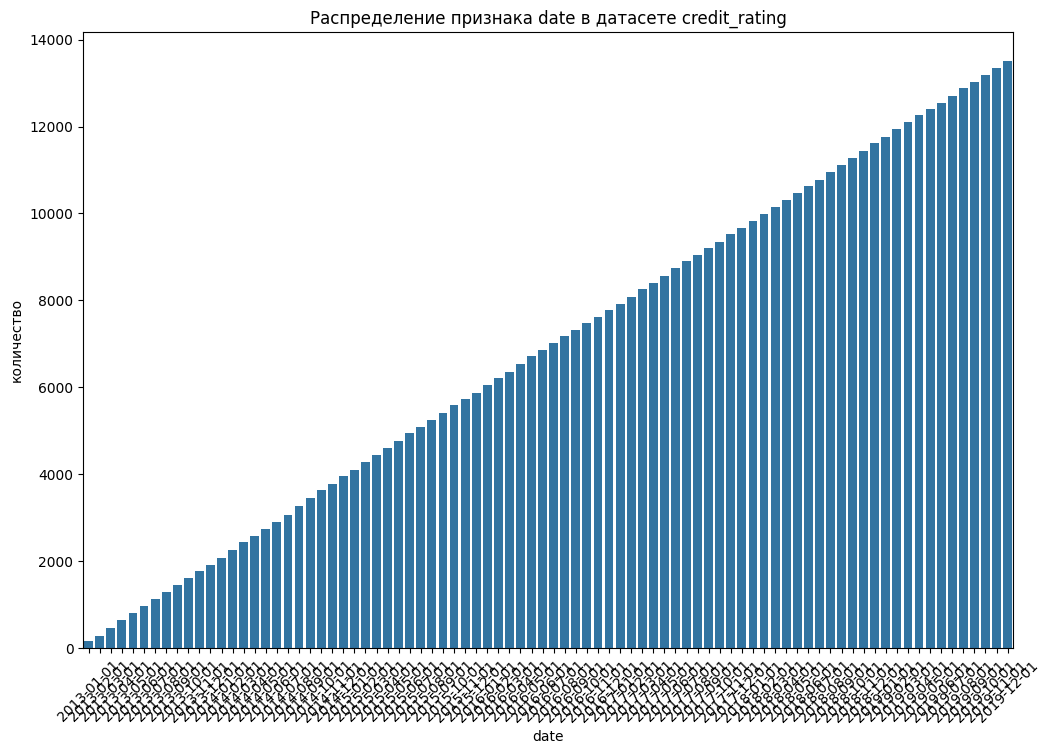

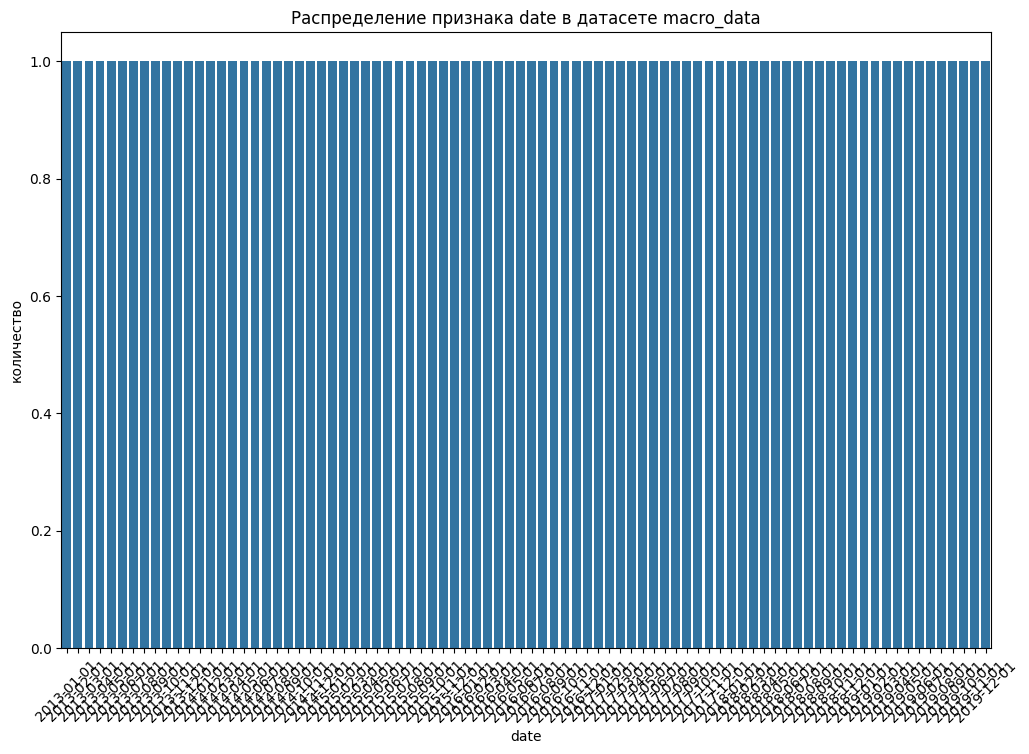

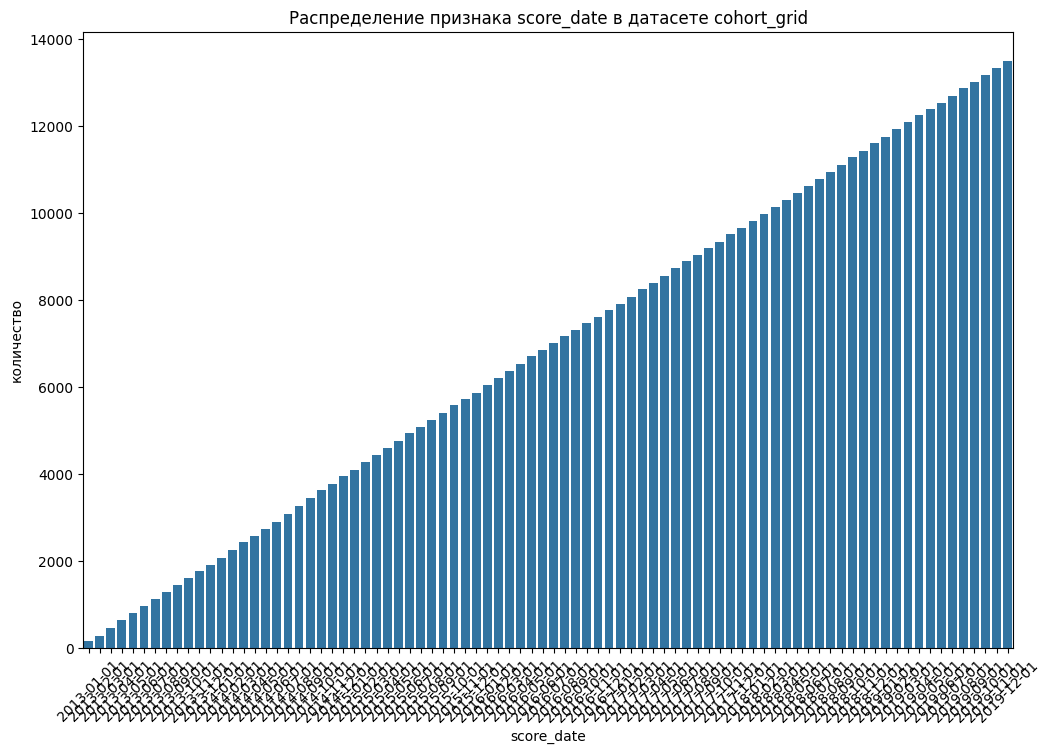

In [39]:
for df, df_name in zip(df_list, df_names):
    cat_col_names, _ = get_cat_num_cols(df)
    cat_col_names = [name for name in cat_col_names if name not in ['ID']]
    for name in cat_col_names:
        plot_count_bars(df=df, col_name=name, df_name=df_name)

Анализ:
- неявных пропусков в виде флагов невалидности нет
- дата начала периода просрочки: -- линейный рост количества записей до середины 2014 года, долее распределение равномерное, со 2ой половины 2018 количество записей в месяц существенно возросло (в 2 раза)
- Количество записей о датах транзакций растет линейно 
- по признаку семейного пложения дисбаланса нет 
- даты регистраций распределены равномерно 
- по датам открытия ипотеки распределение не имеет четкой структуры: в основном распрелеление равномерное, но местами есть пики и просадки
- количество дат датасете по кредитным рейтингам растет линейно 
- даты записей макроэкономических показателей равномерно распрелены - по одной записи на дату
- количество дат скоринга растет линейно

### Вывод по ИАД

#### Общие сведения

Данные представлены в виде 8 таблиц:
- Данные о просрочке платежа: loan_payment_credit
- Месячные транзакции клиента: transactions
- Описание клиента на момент регистрации в банке: client_description
- Описание кредита: credit_description
- Данные о наличии ипотеки: mortgage_presence
- Данные о кредитном рейтинге клиента: credit_rating
- Данные о макроэкономических показателях России: macro_data
- Данные о дате проведения поведенческого скоринга: cohort_grid

Типы данных соотвествуют описанию. 

#### Пропуски, дубли

- явных и неявных пропусков/дублей в данных не обнаружено


#### Анализ распределений

Количественные данные:
- loan_payment_credit: значение дней просрочек равномерно распределено по диапазону
- transactions: траты по кодам MCC имеют скошенное влево распределение. Присутствуют малочисленные выбросы -- большие траты
- client_description: по возрасту распределение равномерное
- client_description: наличие иждевенцев представлено в примерно равных долях 
- credit_description: по доходу и сумме кредита распределение равномерное 
- mortgage_presence: данные по наличию ипотеки принимают одно значнение - 1
- credit_rating: распределение по кредитному рейтингу симметричное, присутсвуют выбросы по краям. Имеются сгустки плотности на некоторых значениях. Выдвинуто предположение, что в происходило округление или имеются стандратные рейтинги для каких-то категорий граждан.
- macro_data: Распределение по учетной ставке несимметричное и имеет малый набор уникальных значений
- macro_data: По безработице распределение симметричное без выбросов
- macro_data: По инфляции распределение симметричное, есть выбросы 

Категириальные данные:
- loan_payment_credit: дата начала периода просрочки: -- линейный рост количества записей до середины 2014 года, долее распределение равномерное, со 2ой половины 2018 количество записей в месяц существенно возросло (в 2 раза)
- transactions: Количество записей о датах транзакций растет линейно 
- client_description: по признаку семейного пложения дисбаланса нет 
- credit_rating: даты регистраций распределены равномерно 
- mortgage_presence: по датам открытия ипотеки распределение не имеет четкой структуры: в основном распрелеление равномерное, но местами есть пики и просадки
- credit_rating: количество дат в датасете по кредитным рейтингам растет линейно 
- macro_data: даты записей макроэкономических показателей равномерно распределены - по одной записи на дату
- cohort_grid: количество дат скоринга растет линейно



## 3. Предобработка данных

### Объединение таблиц

Соберите все источники данных о клиентах в единую таблицу наблюдений.

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

### Создание итоговой таблицы

1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендации:
>* Не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.
>* При формировании таблицы следите за тем, чтобы в ней была корректно проведена работа со временем:
  >   * Отследите, не упущены ли какие-то данные из прошлого;
  >   * Проконтролируйте, верно ли рассчитана целевая переменная, которая зависит от дефолта в будущем.
>* Помните, что даты в исходных таблицах указаны на первое число месяца. Учитывайте период, который они описывают.

Сделайте выводы о получившейся таблице.

### Создание новых признаков

* Добавьте в таблицу новые признаки, которые помогли бы описать поведение клиента. Создайте не менее двух новых признаков.
* Сделайте выводы о новых признаках.

### Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.

## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

1. Цель и задачи исследования.

2. Подготовка данных и выборок.

3. Поиск и настройка модели.

4. Калибровка вероятностей.

5. Оптимизация бизнес-порога.

6. Анализ важности признаков.

7. Финальный пайплайн.

8. Основные выводы и рекомендации для бизнеса.
